In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import seaborn as sns
import math
#from plotnine import *
#import scvi
import os
import pickle

import seaborn as sns
#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(5,5))
%matplotlib inline
sc.settings.verbosity = 0


In [2]:
DATA_PREPARED=True

In [3]:
if DATA_PREPARED:
    adata_iii=sc.read_h5ad("/nfs/team361/ls34/inflow/final_adatas/adata_eczema_scrna.h5ad")
else:
    adata=sc.read_h5ad("/nfs/team361/ls34/inflow/final_adatas/adata_all_scrna.h5ad")






In [4]:
if not DATA_PREPARED: 
    adata.obs["Site_status_binary"]=adata.obs["Site_status_simple"]
    adata_i=adata[adata.obs["Patient_status"]=="Eczema"]
    adata_i.obs["Site_status_binary"].value_counts()
    mapping_dict = {'SKN8090524': ['E2'],
     'SKN8090525': ['E2'],
     'SKN8090526': ['E2'],
     'SKN8090527': ['E2'],
     'SKN8090528': ['E2'],
     'SKN8090529': ['E2'],
     'SKN8090530': ['E2'],
     'SKN8090531': ['E2'],
     'SKN8090536': ['E3'],
     'SKN8090537': ['E3'],
     'SKN8090538': ['E3'],
     'SKN8090539': ['E3'],
     'SKN8090540': ['E3'],
     'SKN8090541': ['E3'],
     'SKN8090542': ['E3'],
     'SKN8090543': ['E3'],
     'SKN8090548': ['E4'],
     'SKN8090549': ['E4'],
     'SKN8090550': ['E4'],
     'SKN8090551': ['E4'],
     'SKN8090552': ['E4'],
     'SKN8090553': ['E4'],
     'SKN8090554': ['E4'],
     'SKN8090555': ['E4'],
     'SKN8090560': ['E1'],
     'SKN8090561': ['E1'],
     'SKN8090562': ['E1'],
     'SKN8090563': ['E1'],
     'SKN8090564': ['E1'],
     'SKN8090565': ['E1'],
     'SKN8090566': ['E1'],
     'SKN8090567': ['E1'],
     'SKN8090576': ['P1'],
     'SKN8090577': ['P1'],
     'SKN8090578': ['P1'],
     'SKN8090579': ['P1'],
     'SKN8090580': ['P1'],
     'SKN8090581': ['P1'],
     'SKN8090582': ['P1'],
     'SKN8090583': ['P1'],
     'SKN8090588': ['P2'],
     'SKN8090589': ['P2'],
     'SKN8090590': ['P2'],
     'SKN8090591': ['P2'],
     'SKN8090592': ['P2'],
     'SKN8090593': ['P2'],
     'SKN8090594': ['P2'],
     'SKN8090595': ['P2'],
     'SKN8090600': ['P3'],
     'SKN8090601': ['P3'],
     'SKN8090602': ['P3'],
     'SKN8090603': ['P3'],
     'SKN8090604': ['P3'],
     'SKN8090605': ['P3'],
     'SKN8090606': ['P3'],
     'SKN8090607': ['P3'],
     'SKN8104894': ['S4'],
     'SKN8104895': ['S4'],
     'SKN8104896': ['S4'],
     'SKN8104897': ['S4'],
     'SKN8104899': ['S4'],
     'SKN8104900': ['S4'],
     'SKN8104901': ['S4'],
     'SKN8104902': ['S4'],
     'SKN8105192': ['S5'],
     'SKN8105193': ['S5'],
     'SKN8105194': ['S5'],
     'SKN8105195': ['S5'],
     'SKN8105197': ['S5'],
     'SKN8105198': ['S5'],
     'SKN8105199': ['S5'],
     'SKN8105200': ['S5'],
     '4820STDY7388991': ['s1'],
     '4820STDY7388992': ['s1'],
     '4820STDY7388993': ['s1'],
     '4820STDY7388994': ['s1'],
     '4820STDY7388995': ['s1'],
     '4820STDY7388996': ['s1'],
     '4820STDY7388997': ['s1'],
     '4820STDY7388998': ['s1'],
     '4820STDY7388999': ['s2'],
     '4820STDY7389000': ['s2'],
     '4820STDY7389001': ['s2'],
     '4820STDY7389002': ['s2'],
     '4820STDY7389003': ['s2'],
     '4820STDY7389004': ['s2'],
     '4820STDY7389005': ['s2'],
     '4820STDY7389006': ['s2'],
     '4820STDY7389007': ['s3'],
     '4820STDY7389008': ['s3'],
     '4820STDY7389009': ['s3'],
     '4820STDY7389010': ['s3'],
     '4820STDY7389011': ['s3'],
     '4820STDY7389012': ['s3'],
     '4820STDY7389013': ['s3'],

     '4820STDY7389014': ['s3']}
    adata_i.obs["DonorID"] = (
        adata_i.obs["sample_id"]
        .map(lambda x: mapping_dict.get(x, [x])[0])
    )
    print(adata_i.obs["DonorID"].value_counts())
    print(adata_i[adata_i.obs["DonorID"]=="E1"].obs.Site_status_simple.value_counts())
    RENAME = {'E2': 'E2',
     'E3': 'E3',
     'E4': 'E4',
     'E1': 'E1',
     'GSM6595214': 'GSM6595214',
     'GSM6595212': 'GSM6595212',
     'GSM6595211': 'GSM6595211',
     'GSM6595213': 'GSM6595213',
     'GSM6595210': 'GSM6595210',
     'AD10': 'AD10',
     'AD11': 'AD11',
     'AD12': 'AD12',
     'AD13': 'AD13',
     'AD14': 'AD14',
     'AD15': 'AD15',
     'AD16': 'AD16',
     'AD17': 'AD17',
     'AD18': 'AD18',
     'AD19': 'AD19',
     'AD1': 'AD1',
     'AD2': 'AD2',
     'AD3': 'AD3',
     'AD4': 'AD4',
     'AD5': 'AD5',
     'AD6': 'AD6',
     'AD7': 'AD7',
     'AD8': 'AD8',
     'BCH01-L1': 'BCH01',
     'BCH01-NL1': 'BCH01',
     'BCH01-NL2': 'BCH01',
     'BCH01-L2': 'BCH01',
     'BCH04-NL2': 'BCH04',
     'BCH04-NL1': 'BCH04',
     'BCH04-L1': 'BCH04',
     'BCH04-L2': 'BCH04',
     'BCH05-NL': 'BCH05',
     'BCH05-L': 'BCH05',
     'BCH06-NL': 'BCH06',
     'BCH06-L': 'BCH06',
     'BCH07-NL': 'BCH07',
     'BCH07-L': 'BCH07',
     'MGH103-NL1': 'MGH103',
     'MGH103-L2': 'MGH103',
     'MGH103-L1': 'MGH103',
     'MGH103-NL2': 'MGH103',
     'MGH104-L1': 'MGH104',
     'MGH104-L2': 'MGH104',
     'MGH104-NL1': 'MGH104',
     'MGH105-L1': 'MGH105',
     'MGH106-L1': 'MGH106',
     'MGH106-L2': 'MGH106',
     'MGH106-NL1': 'MGH106',
     'MGH106-NL2': 'MGH106',
     'MGH108-L1': 'MGH108',
     'MGH108-L2': 'MGH108',
     'MGH108-NL1': 'MGH108',
     'MGH108-NL2': 'MGH108',
     'MGH110-NL': 'MGH110',
     'MGH110-L': 'MGH110'}
    adata_i.obs["DonorID"]=adata_i.obs["DonorID"].map(RENAME).fillna(adata_i.obs["DonorID"])
    print(adata_i[adata_i.obs["DonorID"]=="E1"].obs.Site_status_simple.value_counts())

In [5]:
if not DATA_PREPARED:
    adata_ii = adata_i[~adata_i.obs["DonorID"].str.startswith("GSM")]
    adata_ii = adata_ii[~adata_ii.obs["DonorID"].str.startswith("AD")]
    adata_ii.obs["validation"] = adata_ii.obs["DonorID"].astype(str)  + "_" + adata_ii.obs["Site_status_binary"].astype(str) 
    adata_ii.obs["validation2"] = adata_ii.obs["Site_status_binary"].astype(str)  + "_" +  adata_ii.obs["DonorID"].astype(str) 
        # # ### NORMALISE
    #adata_ii.layers["counts"]=adata_ii.X.copy()
    # adata.layers["counts"]=adata.X.copy()
    sc.pp.normalize_total(adata_ii, target_sum=1e4)
    sc.pp.log1p(adata_ii)
    adata_iii=adata_ii[adata_ii.obs["dataset_id"]=="Reynolds"]
    adata_ii.write("/nfs/team361/ls34/inflow/final_adatas/adata_eczema_scrna.h5ad")
    import gc
    gc.collect()

In [6]:
with open('eczema_tdc_mcp_top200.pkl', 'rb') as f:
    gene_programme200 = pickle.load(f)




# reynolds

In [7]:
adata_iii[adata_iii.obs["DonorID"]=="E1"].obs.Site_status.value_counts()

Site_status
Nonlesional    2794
Lesional       2577
Name: count, dtype: int64

/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


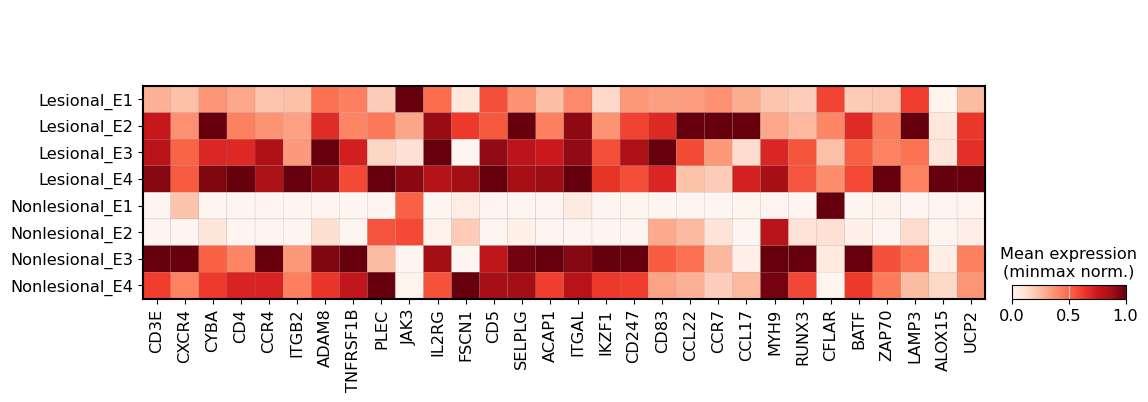

In [8]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds",
                categories_order=sorted(list(adata_iii.obs["validation2"].unique())),
                 colorbar_title="Mean expression\n(minmax norm.)"
                )
 